# Required packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [42]:
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from tqdm.notebook import tqdm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox

In [18]:
from itertools import product
import warnings

# Exercise 1

## Getting data

In [5]:
macro_data = sm.datasets.macrodata.load_pandas()

In [6]:
macro_econ = macro_data['data']

In [7]:
macro_econ.info()

<class 'pandas.DataFrame'>
RangeIndex: 203 entries, 0 to 202
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   year      203 non-null    float64
 1   quarter   203 non-null    float64
 2   realgdp   203 non-null    float64
 3   realcons  203 non-null    float64
 4   realinv   203 non-null    float64
 5   realgovt  203 non-null    float64
 6   realdpi   203 non-null    float64
 7   cpi       203 non-null    float64
 8   m1        203 non-null    float64
 9   tbilrate  203 non-null    float64
 10  unemp     203 non-null    float64
 11  pop       203 non-null    float64
 12  infl      203 non-null    float64
 13  realint   203 non-null    float64
dtypes: float64(14)
memory usage: 22.3 KB


In [8]:
target = macro_econ['realgdp']
exog = macro_econ[
    ['realcons', 'realinv', 'realgovt', 'realdpi', 'cpi', 
     'm1', 'tbilrate', 'unemp', 'pop', 'infl', 'realint']
]

## Choosing model

In [25]:
def optimize_SARIMAX(
    endog: Union[list, tuple, pd.Series],
    exog: Union[pd.DataFrame],
    order_list: Union[tuple, list],
) -> pd.DataFrame:
    """
    Find the best SARIMAX model using AIC.

    Params:
    --------
    endog: Union[list, tuple, pd.Series]
        target variable
    exog: Union[pd.DataFrame]
        exogenous variables
    order_list: Union[tuple, list]
        a list or a tuple with of tuples (or lists) with p, d, q, P, D, Q, m

    Returns:
    ---------
    Returns a pd.DataFrame object with p, d, q, P, D, Q, AIC.
    """
    results = []

    for order in tqdm(orderlist):
        try:
            with warnings.catch_warnings():
                 warnings.simplefilter("ignore")
                 model = SARIMAX(
                    endog, exog,
                    order=order[:3],
                    seasonal_order=order[3:],
                    simple_differencing=False
                 ).fit(disp=False)
            results.append([*order, model.aic])
        except:
            continue


    result_df = pd.DataFrame(results, columns=('p', 'd', 'q', 'P', 'D', 'Q', 'm', 'AIC'))
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)

    return result_df

In [32]:
orderlist = list(product(
    range(4), [1], range(4), range(4), [0], range(4), [4]
)) # integration order previsouly analyzed

df_aic = optimize_SARIMAX(target, exog, orderlist)

df_aic.to_csv('output/chapter_9_exercise_aic.csv', index=False)

In [35]:
df_aic = pd.read_csv('output/chapter_9_exercise_aic.csv')

In [36]:
df_aic.head()

,p,d,q,P,D,Q,m,AIC
0,3,1,3,2,0,2,4,1792.703440
1,3,1,3,2,0,3,4,1794.255756
2,3,1,3,3,0,2,4,1794.382393
3,0,1,0,2,0,2,4,1794.598514
4,2,1,2,0,0,0,4,1795.691518


## Fitting the model

In [37]:
target_train = target[:196]
exog_train = exog[:196]
target_test = target[196:]
exog_test = exog[196:]

In [38]:
best_model = SARIMAX(
    target_train, exog_train,
    order=(3, 1, 3),
    seasonal_order=(2, 0, 2, 4),
    simple_differencing=False
).fit(disp=False)

/home/gilberto/anaconda3/envs/timeseries/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [39]:
print(best_model.summary())

                                       SARIMAX Results                                        
Dep. Variable:                                realgdp   No. Observations:                  196
Model:             SARIMAX(3, 1, 3)x(2, 0, [1, 2], 4)   Log Likelihood                -839.068
Date:                                Thu, 04 Jun 2026   AIC                           1722.136
Time:                                        08:59:17   BIC                           1794.142
Sample:                                             0   HQIC                          1751.291
                                                - 196                                         
Covariance Type:                                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
realcons       0.9222      0.058     15.999      0.000       0.809       1.035
rea

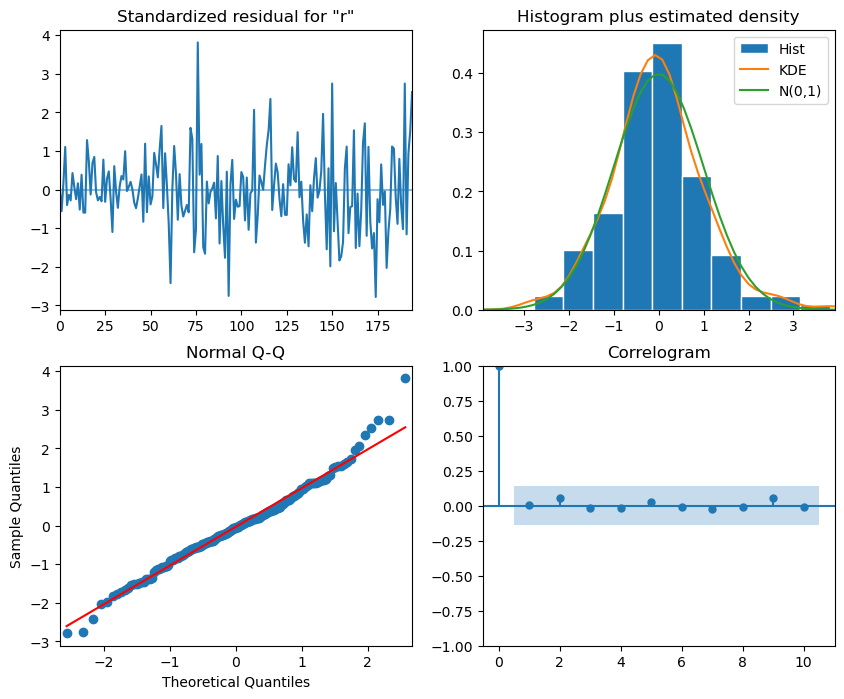

In [55]:
best_model.plot_diagnostics(figsize=(10,8));

In [43]:
resid = best_model.resid
df_lb = acorr_ljungbox(resid, lags=20)

In [44]:
df_lb

,lb_stat,lb_pvalue
1,0.000081,0.992798
2,0.030735,0.984750
3,0.035543,0.998237
4,0.132822,0.997890
5,0.144128,0.999602
6,0.144181,0.999941
7,0.145379,0.999992
8,0.163908,0.999998
9,0.164039,1.000000
10,0.165506,1.000000


## Forecasting (recursive forecasting)

In [45]:
def recursive_forecast(
    endog: Union[pd.Series, list], exog: Union[pd.DataFrame],
    train_len: int, horizon: int, window:int,
    method: str, 
    order: Union[tuple, list] = (2, 1, 3), seasonal_order: Union[tuple, list] = (0, 0, 0, 4)
) -> list:
    """
    Recursive forecast to evaluate the forecasting methods.

    Params:
    --------
    endog: Union[pd.Series, list]
        Endogenous time series.
    exog: Union[pd.DataFrame]
        Exogenous time series.
    train_len: int
        Sample size used to train.
    horizon: int
        Horizon to forecast.
    window:
        Window of forecast.
    order: Union[tuple, list]
        ARIMA order of SARIMAX.
    seasonal_order: Union[tuple, list]
        Seasonal order of SARIMAX.

    Returns:
    ---------
        A list with horizon elements.
    """
    total_len = train_len + horizon

    if method == 'last':
        pred = []

        for i in tqdm(range(train_len, total_len, window), desc='Last value'):
            last_value = endog[:i].iloc[-1]
            pred.extend(last_value for _ in range(window))
        return pred
    elif method == 'sarimax':
        pred = []
        
        for i in tqdm(range(train_len, total_len, window), desc='SARIMAX'):
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                model = SARIMAX(
                    endog[:i], exog[:i], order = order, seasonal_order=seasonal_order,
                    simple_differencing=False
                ).fit(disp=False)
                predictions = model.\
                    get_prediction(exog=exog).predicted_mean
            pred.extend(predictions[-window:])
        return pred
            
    else:
        raise Exception("'method' must be 'last' or 'sarimax'.")

In [47]:
target_train = target[:196]
target_test = target[196:]
WINDOW = 1
TRAIN_LEN = len(target_train)
HORIZON = len(target_test)

In [48]:
HORIZON

7

In [49]:
df_pred = pd.DataFrame({
    'observed': target_test,
    'last_value': recursive_forecast(target, exog, TRAIN_LEN, HORIZON, WINDOW, 'last'),
    'sarimax': recursive_forecast(target, exog, TRAIN_LEN, HORIZON, WINDOW, 'sarimax'),
}, index=target_test.index)

Last value:   0%|          | 0/7 [00:00<?, ?it/s]

SARIMAX:   0%|          | 0/7 [00:00<?, ?it/s]

In [50]:
df_pred

,observed,last_value,sarimax
196,13366.865,13391.249,13340.639615
197,13415.266,13366.865,13378.403355
198,13324.600,13415.266,13375.035340
199,13141.920,13324.600,13329.816616
200,12925.410,13141.920,13135.897475
201,12901.504,12925.410,12893.045263
202,12990.341,12901.504,12867.576573


In [51]:
mape = lambda y, p: np.mean(np.abs((y-p) / p) * 100)

In [52]:
series_mape = pd.Series({
    'last': mape(df_pred.observed, df_pred.last_value),
    'sarimax': mape(df_pred.observed, df_pred.sarimax)
})

In [53]:
series_mape

last       0.730291
sarimax    0.697265
dtype: float64

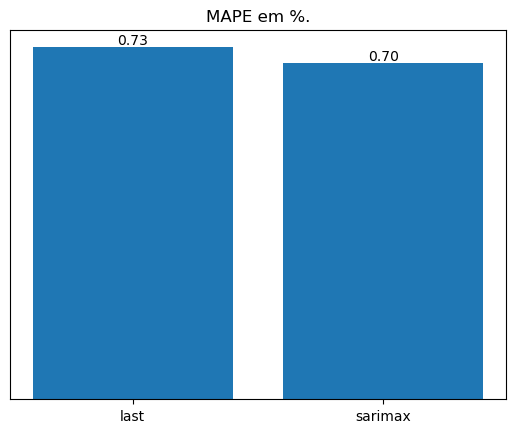

In [54]:
fig, ax = plt.subplots()
bars = ax.bar(series_mape.index, series_mape.values)
ax.bar_label(bars, fmt='%.2f')
ax.set_yticks([])
ax.set_title('MAPE em %.')
plt.show()